In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import random

In [3]:
RAW_DIR = "Data/Raw"
PROCESSED_DIR = "Data/Processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [4]:
classes = sorted(os.listdir(RAW_DIR))
print("Classes:", classes)

Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


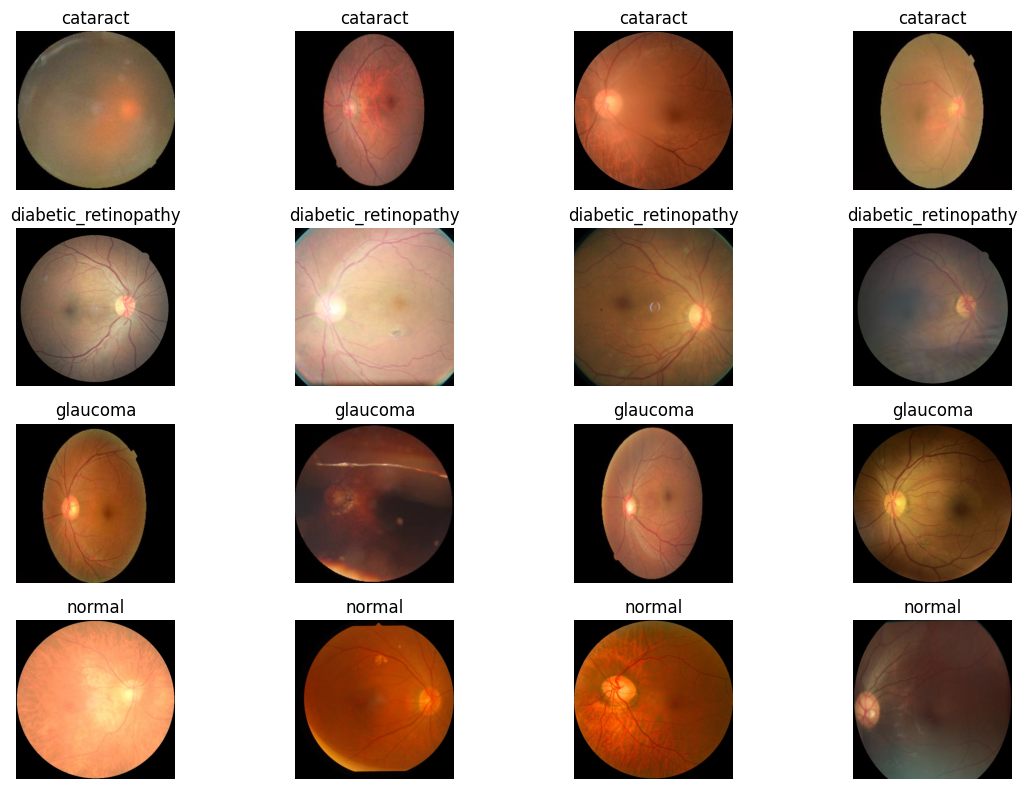

In [5]:
# visualize images from each class
def show_images():
    plt.figure(figsize=(12, 8))
    
    for i, cls in enumerate(classes):
        images = glob(os.path.join(RAW_DIR, cls, "*"))
        sample_images = random.sample(images, min(4, len(images)))
        for j, img_path in enumerate(sample_images):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(classes), 4, i*4 + j + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_images()

In [6]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return img

In [7]:
def preprocess_image(img):
    # resize
    img = cv2.resize(img, (224, 224))
    # CLAHE
    img = apply_clahe(img)
    # Normalize 0/1
    img = img / 255.0
    return img

In [8]:
def augment_image(img):
    augmented_images = []
    # Rotation
    angle = random.choice([-15, -10, 10, 15])
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1) # 1 means no zoom 
    rotated = cv2.warpAffine(img, M, (w, h))
    augmented_images.append(rotated)
    # Brightness adjustment
    value = random.randint(-30, 30)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv = hsv.astype(np.int16)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] + value, 0, 255)
    hsv = hsv.astype(np.uint8)
    bright = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    augmented_images.append(bright)
    return augmented_images

In [9]:
for cls in classes:
    input_folder = os.path.join(RAW_DIR, cls)
    output_folder = os.path.join(PROCESSED_DIR, cls)
    os.makedirs(output_folder, exist_ok=True)
    images = glob(os.path.join(input_folder, "*"))
    for img_path in images:
        img = cv2.imread(img_path)
        # Safety check
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        processed = preprocess_image(img)
        filename = os.path.basename(img_path)
        name, ext = os.path.splitext(filename)
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, (processed * 255).astype(np.uint8))
        aug_images = augment_image(img)
        for i, aug in enumerate(aug_images):
            aug_processed = preprocess_image(aug)
            aug_filename = f"{name}_aug{i}{ext}"
            aug_path = os.path.join(output_folder, aug_filename)
            cv2.imwrite(aug_path, (aug_processed * 255).astype(np.uint8))
print("Preprocessing done!")

Preprocessing done!
